importing datasets

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt
import math
import sklearn 

In [40]:
import pickle
from joblib import load as joblib_load

train_df = pd.read_csv(
	r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\notebooks\test_df.csv")
val_df = pd.read_csv(r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\notebooks\val_df.csv")
test_df = pd.read_csv(r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\notebooks\test_df.csv")
X_train_pca = pd.read_csv(r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\notebooks\X_train_pca.csv")
pca_path = r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\notebooks\pca_model.pkl"

try:
    with open(pca_path, "rb") as f:
        pca_model = pickle.load(f)
except Exception:
    pca_model = joblib_load(pca_path)

## We start with the baseline models

In [41]:
X_train = train_df.drop(columns=["defaulted_flag"]).copy()
y_train = train_df["defaulted_flag"].copy()
X_val = val_df.drop(columns=["defaulted_flag"]).copy()
y_val = val_df["defaulted_flag"].copy()
X_test = test_df.drop(columns=["defaulted_flag"]).copy()
y_test = test_df["defaulted_flag"]

MemoryError: Unable to allocate 26.3 MiB for an array with shape (23, 150000) and data type float64

#### Dummy Classifier

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create dummy classifier
dummy = DummyClassifier(strategy="most_frequent")

# Fit
dummy.fit(X_train, y_train)

# Predictions
y_pred = dummy.predict(X_val)

# Probabilities
y_prob = dummy.predict_proba(X_val)[:, 1]

# Metrics
print("Accuracy :", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred, zero_division=0))
print("Recall   :", recall_score(y_val, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_val, y_pred, zero_division=0))
print("ROC AUC  :", roc_auc_score(y_val, y_prob))

Accuracy : 0.91042
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
ROC AUC  : 0.5


In [ ]:
print(y_train.mean(),
    y_val.mean(),
    y_test.mean())

0.021153333333333333 0.08958 0.021153333333333333


#### Logistic Regression

#first of all we check the assumptions
1. The target vars are already known to be cateogerical to be precise binary here
2. The obsns are mostly independently collected through data and rest of the dependents have been already dropped.
3. checking no perfect multicoolinearity
4. lineatr relo btwn predictors and log odds
5. no extreme outliers
6. sufficient sample size


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# checking multicolinearity
correlation = X_train.corr().abs()

high_corr = (
    correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
)
print(high_corr.stack().sort_values(ascending=False).head(20))

# ---- prepare dataframe for VIF calculation ----
x_vif = X_train.select_dtypes(include=[np.number]).copy()

# Drop rows with any remaining NaN/inf (VIF cannot handle these)
x_vif = x_vif.replace([np.inf, -np.inf], np.nan).dropna()

# 1) Drop exactly-constant columns
zero_var = x_vif.columns[x_vif.std() == 0]
if len(zero_var) > 0:
    print("Dropping zero-variance columns:", list(zero_var))
    x_vif = x_vif.drop(columns=zero_var)

# 2) Drop near-constant columns (std/mean ratio tiny, e.g. unit_no almost always 1)
#    statsmodels VIF is unstable on near-singular columns even if std != 0 exactly
near_const_thresh = 1e-3
near_const = x_vif.columns[x_vif.std() < near_const_thresh]
if len(near_const) > 0:
    print("Dropping near-constant columns:", list(near_const))
    x_vif = x_vif.drop(columns=near_const)

# 3) CRITICAL: add an intercept/constant column before computing VIF.
#    Without this, statsmodels regresses each feature on the others with
#    no intercept, which is numerically unstable and a common cause of
#    inf VIF values, especially for non-centered features like WOE columns.
x_vif_const = sm.add_constant(x_vif)

vif_values = []
feature_names = []

for i, col in enumerate(x_vif_const.columns):
    if col == "const":
        continue
    try:
        vif = variance_inflation_factor(x_vif_const.values, i)
    except Exception:
        vif = np.inf
    vif_values.append(vif)
    feature_names.append(col)

vif_df = pd.DataFrame({
    "Feature": feature_names,
    "VIF": vif_values
})
vif_df = vif_df.sort_values("VIF", ascending=False)
vif_df


og_ltv                      credit_ltv_interaction     0.969767
og_dti                      dti_rate_interaction       0.925432
cltv_minus_ltv              cltv_ltv_ratio             0.892415
og_int_rate                 credit_rate_interaction    0.891135
og_dti                      dti_ltv_interaction        0.796816
dti_ltv_interaction         dti_rate_interaction       0.781127
og_int_rate                 fp_vintage                 0.724849
og_ltv                      dti_ltv_interaction        0.673955
fp_vintage                  credit_rate_interaction    0.673127
dti_ltv_interaction         credit_ltv_interaction     0.619716
og_int_rate                 dti_rate_interaction       0.554132
credit_rate_interaction     dti_rate_interaction       0.435660
mortgage_insurance_percent  og_ltv                     0.430537
servicer_name_woe           seller_name_woe            0.408353
mortgage_insurance_percent  credit_ltv_interaction     0.401340
fp_vintage                  dti_rate_int

,Feature,VIF
5,og_ltv,324.620900
21,credit_ltv_interaction,288.183745
6,og_int_rate,263.352291
20,credit_rate_interaction,221.337884
22,dti_rate_interaction,72.192900
0,cred_score,56.891052
3,og_dti,55.540543
19,dti_ltv_interaction,29.273547
18,cltv_ltv_ratio,5.067116
17,cltv_minus_ltv,4.999448


In [ ]:
inf_count = np.isinf(train_df.select_dtypes(include=[np.number])).sum().sum()
inf_count

np.int64(0)

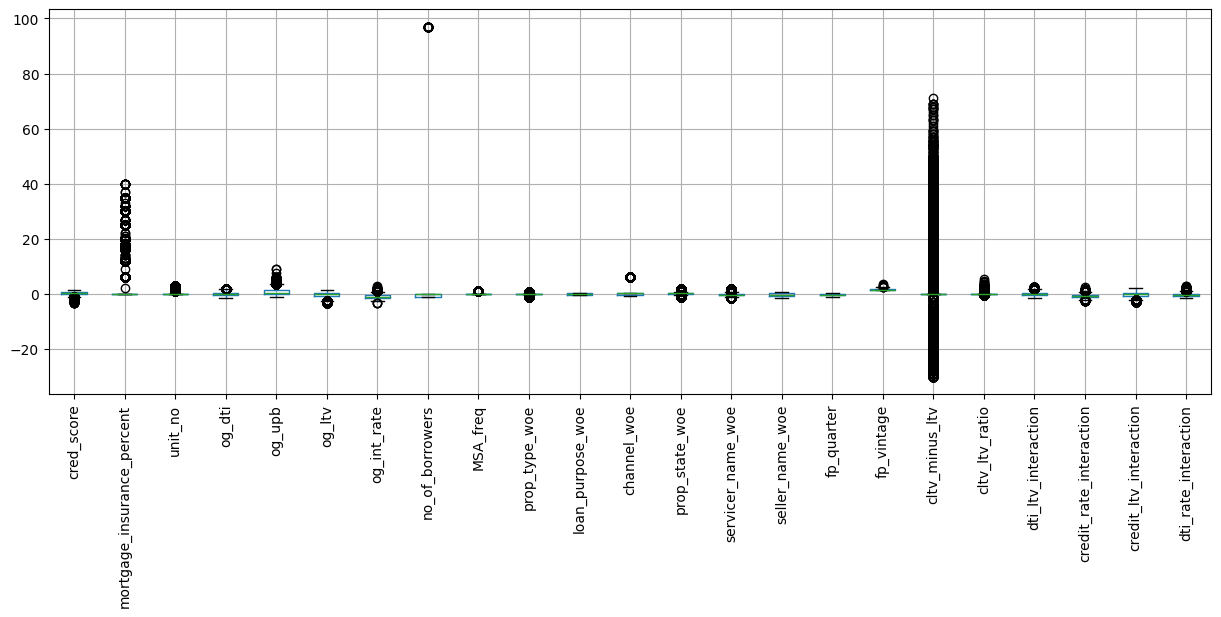

In [ ]:
import matplotlib.pyplot as plt

X_train.boxplot(figsize=(15, 5))
plt.xticks(rotation=90)
plt.show()

therefore we do not observe and multicoolinearity except for the dates and no outliers detected

now basically we first fit the model and then see if the class imbalance hurts, if it does then deal with that problem

In [ ]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

In [ ]:
#fitting the model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

y_prob = model.predict_proba(X_val)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

ValueError: Found input variables with inconsistent numbers of samples: [150000, 50000]

#### Linear Discriminant Analysis

though a few assumptions we checked werent fullfilled earlier such as normality of features